# Detección de Fraude — Redes Neuronales (MLP)

**Dataset:** Credit Card Fraud Detection (Kaggle, features anonimizadas vía PCA).
**Tarea:** clasificación binaria **extremadamente desbalanceada** (fraude ≈ 0.17 %).
**Métrica principal:** **PR-AUC** (Average Precision), *no* accuracy.

### Por qué este enfoque
| Rúbrica | Dónde se cubre en este notebook |
|---|---|
| 1. Preprocesamiento (escalado crítico para redes) | 2 — escalado robusto de `Amount`/`Time`, split estratificado, *sin fuga de datos* |
| 3. Redes + validación cruzada | 4–5 (MLP 1–3 capas), 8 (StratifiedKFold) |
| 4. Optimización de pérdida / pesos | 3 — `pos_weight` en `BCEWithLogitsLoss` + `weight_decay` (L2) |
| 5. Interpretación y juicio | 6–10 — PR-AUC, ajuste de umbral, AdaBoost vs MLP |

> **Idea clave:** con 0.17 % de positivos, un modelo que prediga "todo legítimo" logra ~99.83 % de accuracy y **0 % de recall**. Por eso medimos con PR-AUC y ajustamos el umbral, no con accuracy.

---


## 0. Reproducibilidad e imports
Fijamos todas las semillas (Python, NumPy, PyTorch) para que el resultado sea reproducible, como exige el entregable (`seed fijo`).

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, classification_report, f1_score,
)
from sklearn.ensemble import AdaBoostClassifier

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)  # CPU es suficiente: la red es pequeña


Dispositivo: cpu


## 1. Configuración y carga de datos
Cargamos con `kagglehub`, igual que en `1_Preprocesamiento_y_EDA.ipynb`, para no duplicar rutas locales.

In [2]:
import kagglehub

# Hiperparámetros del MLP (centralizados para reproducibilidad)
HIDDEN_DIMS = [32, 16]   # 2 capas ocultas (la rúbrica pide 1–3)
DROPOUT     = 0.3
LR          = 1e-3
WEIGHT_DECAY= 1e-4       # = regularización L2 (conecta con el tema Ridge del proyecto)
BATCH_SIZE  = 2048
MAX_EPOCHS  = 40
PATIENCE    = 6          # early stopping sobre PR-AUC de validación

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print("Forma:", df.shape)
print(df["Class"].value_counts())
frac = df["Class"].mean()
print(f"Proporción de fraude: {frac:.4%}")


c:\Users\angel\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Forma: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Proporción de fraude: 0.1727%


## 2. Preprocesamiento

**Razonamiento (para el informe):**
- Las variables `V1`–`V28` ya son **componentes principales (PCA)**, por lo que están centradas y en escalas comparables. *No* las re-escalamos para no destruir esa estructura.
- `Amount` y `Time` **no** pasaron por PCA y tienen rangos enormes y colas largas → una red neuronal con entradas sin escalar sufre gradientes mal condicionados. Usamos **`RobustScaler`** (mediana e IQR) porque es resistente a los *outliers* severos típicos del fraude.
- **Sin fuga de datos:** el escalador se ajusta **solo con el conjunto de entrenamiento** y luego se aplica a validación/test.
- **Split estratificado** para preservar la proporción de fraude (~0.17 %) en cada partición; con clases tan raras, un split aleatorio simple podría dejar casi sin positivos a validación/test.

In [3]:
X = df.drop(columns=["Class"]).copy()
y = df["Class"].astype(int).values

# Split estratificado: 60% train / 20% val / 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=SEED)
# 0.25 * 0.80 = 0.20 -> val = 20%

# Escalar SOLO Amount y Time; las V* ya vienen de PCA
cols_to_scale = ["Amount", "Time"]
scaler = RobustScaler().fit(X_train[cols_to_scale])

for part in (X_train, X_val, X_test):
    part[cols_to_scale] = scaler.transform(part[cols_to_scale])

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  fraude en {name}: {yy.mean():.4%}  ({yy.sum()} casos)")


Train/Val/Test: (170883, 30) (56962, 30) (56962, 30)
  fraude en train: 0.1726%  (295 casos)
  fraude en val: 0.1738%  (99 casos)
  fraude en test: 0.1720%  (98 casos)


## 3. Manejo del desbalance vía la función de pérdida

En lugar de re-muestrear (SMOTE/undersampling), penalizamos más fuerte los errores
sobre la clase minoritaria **dentro de la función de pérdida**. Esto es exactamente
"manejo de hiperparámetros de pérdida/pesos en clasificación".

Usamos `BCEWithLogitsLoss(pos_weight = N_neg / N_pos)`: cada fraude mal clasificado
pesa ~`N_neg/N_pos` veces más que un legítimo, lo que recupera el recall sin
re-muestrear.

> Aquí solo aplicamos la ponderación necesaria para entrenar la red. La demostración
> completa de optimización de la pérdida (barrido de `pos_weight`, comparación entre
> modelos) corresponde al notebook 4.

In [4]:
# Calculamos el peso de la clase positiva (fraude) para la pérdida

n_pos = int(y_train.sum()) # nº de fraudes en train (y=1). .sum() los cuenta porque son 1s
n_neg = int(len(y_train) - n_pos) # nº de legítimas = total menos fraudes
pos_weight_value = n_neg / n_pos # cuántas legítimas hay por cada fraude (~578) -> ese será el castigo extra
print(f"pos_weight = {pos_weight_value:.1f}")

# Función que convierte nuestros datos (pandas) en algo que PyTorch
# pueda entrenar: un DataLoader que entrega los datos por lotes (batches)

def make_loader(Xdf, yarr, shuffle): # Pasamos las variables a un tensor float32
    Xt = torch.tensor(Xdf.values, dtype=torch.float32) 
    yt = torch.tensor(yarr, dtype=torch.float32).unsqueeze(1) # Las etiquetas también a float (la pérdida BCE espera floats, no enteros).
    # .unsqueeze(1) cambia la forma de (N,) a (N,1) para que coincida con la salida de la red, que da 1 logit por fila.
    ds = TensorDataset(Xt, yt) # TensorDataset empareja cada fila de X con su etiqueta y.
    g = torch.Generator().manual_seed(SEED)  # Generador con semilla fija: hace que el orden del barajado sea reproducible.
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, generator=g) # DataLoader: sirve los datos en lotes de BATCH_SIZE filas a la vez, shuffle reordena los datos en cada época (solo lo queremos en entrenamiento).

train_loader = make_loader(X_train, y_train, shuffle=True) # Entrenamiento: shuffle=True -> en cada época la red ve los datos en distinto orden, lo que evita que "memorice" la secuencia y estabiliza el aprendizaje.
val_loader   = make_loader(X_val,   y_val,   shuffle=False) # Validación y test: shuffleo=False -> el orden no importa para evaluar, y así la evaluación es siempre determinista (mismos resultados).
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

# nº de columnas de entrada = nº de variables = tamaño de la capa de entrada de la red (30 aquí).
INPUT_DIM = X_train.shape[1] 


pos_weight = 578.3


## 4. Arquitectura del MLP

**Razonamiento:** red **pequeña a propósito**. Con tan pocos positivos, una red grande sobreajusta el ruido de la clase mayoritaria. Bloques: `Linear → BatchNorm → ReLU → Dropout`.
- **BatchNorm** estabiliza el entrenamiento con entradas heterogéneas.
- **Dropout (0.3)** regulariza.
- Salida = **1 logit** (sin sigmoide); la sigmoide vive dentro de `BCEWithLogitsLoss` por estabilidad numérica.

In [5]:
# La red se define como una clase que hereda de nn.Module (lo estándar en PyTorch).
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout): 
        super().__init__() # inicializa la maquinaria interna de nn.Modul
        layers, prev = [], input_dim # 'layers' acumula las capas; 'prev' = tamaño de entrada actual
        # Por cada tamaño de capa oculta (aquí [32, 16]) añadimos un bloque de 4 piezas:
        # 'Linear' capa densa: combina las 'prev' entradas en 'h' salidas (aquí se aprende)
        # 'BatchNorm' normaliza esas h salidas -> entrenamiento más estable y rápido
        # 'ReLu' activación no lineal: deja pasar positivos, anula negativos
        # apaga al azar el 30% de neuronas al entrenar (regularización)
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))  # capa final: 1 logit (sin activación; la sigmoide vive en la pérdida)
        self.net = nn.Sequential(*layers) # encadena todas las capas en orden
    
    def forward(self, x): # forward define cómo fluye un dato 'x' por la red, de la entrada a la salida.
        return self.net(x)

set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE) # crea la red y la envía a CPU (o GPU si hubiera)
print(model)
print("Parámetros:", sum(p.numel() for p in model.parameters()))


MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parámetros: 1633


## 5. Entrenamiento con *early stopping* sobre PR-AUC

Validamos cada época con **Average Precision (PR-AUC)** y guardamos los pesos del mejor estado. `weight_decay` del optimizador Adam aporta **regularización L2**, el mismo principio Ridge.

In [68]:
# @torch.no_grad(): desactiva el rastreo de gradientes en toda esta función (solo predecimos, no entrenamos).
@torch.no_grad()
def predict_proba(model, loader):
    model.eval() # modo evaluación: apaga Dropout y fija BatchNorm
    probs, ys = [], [] # listas para ir guardando probabilidades y etiquetas reales
    for xb, yb in loader: 
        xb = xb.to(DEVICE)
        p = torch.sigmoid(model(xb)).cpu().numpy().ravel() # model(xb) da logits -> sigmoide los pasa a probabilidad -> a CPU, a numpy, y aplanado a 1D
        probs.append(p); ys.append(yb.numpy().ravel())
    return np.concatenate(probs), np.concatenate(ys)

def train_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], device=DEVICE)) # Pérdida ponderada (pos_weight ~578) para castigar más los fraudes mal clasificados
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY) # Optimizador Adam; weight_decay = regularización L2 (idea de Ridge).

    history = {"train_loss": [], "val_loss": [], "val_ap": []}
    best_ap, best_state, bad = -1.0, None, 0 # mejor PR-AUC visto, copia de los mejores pesos, épocas sin mejorar

    for epoch in range(1, max_epochs + 1):
        model.train() # modo entrenamiento: Dropout y BatchNorm activos
        running = 0.0 # acumulador de la pérdida de esta época
        for xb, yb in train_loader: 
            xb, yb = xb.to(DEVICE), yb.to(DEVICE) 
            optimizer.zero_grad() # borramos los gradientes del paso anterior
            loss = criterion(model(xb), yb) # la red predice y medimos el error (forward)
            loss.backward() # backpropagation: calcula cuánto "culpa" tiene cada peso del error
            optimizer.step() # optimizador ajusta los pesos para bajar el error
            running += loss.item() * xb.size(0) # sumamos la pérdida del lote (×tamaño del lote)
        train_loss = running / len(train_loader.dataset) # pérdida media de la época

        # validación
        model.eval()
        with torch.no_grad(): # sin gradientes: más rápido y ligero
            vloss = 0.0
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vloss += criterion(model(xb), yb).item() * xb.size(0) # acumula pérdida de validación
            vloss /= len(val_loader.dataset) # pérdida media de validación
        vp, vy = predict_proba(model, val_loader) # probabilidades y etiquetas de validación
        val_ap = average_precision_score(vy, vp) # PR-AUC de validación (nuestra métrica real)

        history["train_loss"].append(train_loss)  # guardamos métricas para graficar luego
        history["val_loss"].append(vloss)
        history["val_ap"].append(val_ap)
        if verbose:
            print(f"Época {epoch:02d} | train {train_loss:.4f} | val {vloss:.4f} | val PR-AUC {val_ap:.4f}")

         # early stopping basado en el PR-AUC de validación
        if val_ap > best_ap: # ¿mejoró el PR-AUC de validación?
            best_ap, best_state, bad = val_ap, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0 # sí: guardamos ESTOS pesos
        else:
            bad += 1  # no: contamos una época sin mejora
            if bad >= patience: # si van 6 seguidas sin mejorar
                if verbose: print(f"Early stopping en época {epoch} (mejor PR-AUC val: {best_ap:.4f})")
                break # paramos

    if best_state is not None:
        model.load_state_dict(best_state) # restauramos los MEJORES pesos (no los de la última época)
    return model, history, best_ap

set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
model, history, best_val_ap = train_model(model, train_loader, val_loader)


Época 01 | train 0.9559 | val 0.8011 | val PR-AUC 0.5455
Época 02 | train 0.7536 | val 0.6766 | val PR-AUC 0.6730
Época 03 | train 0.6102 | val 0.5782 | val PR-AUC 0.6666
Época 04 | train 0.5067 | val 0.4966 | val PR-AUC 0.6732
Época 05 | train 0.4309 | val 0.4377 | val PR-AUC 0.6747
Época 06 | train 0.3705 | val 0.4064 | val PR-AUC 0.6870
Época 07 | train 0.3405 | val 0.3821 | val PR-AUC 0.6788
Época 08 | train 0.3103 | val 0.3686 | val PR-AUC 0.6675
Época 09 | train 0.2757 | val 0.3747 | val PR-AUC 0.6979
Época 10 | train 0.2534 | val 0.3698 | val PR-AUC 0.6919
Época 11 | train 0.2599 | val 0.3665 | val PR-AUC 0.7017
Época 12 | train 0.2449 | val 0.3818 | val PR-AUC 0.7008
Época 13 | train 0.2338 | val 0.3719 | val PR-AUC 0.7016
Época 14 | train 0.2380 | val 0.3902 | val PR-AUC 0.6967
Época 15 | train 0.2225 | val 0.4113 | val PR-AUC 0.7016
Época 16 | train 0.2364 | val 0.4083 | val PR-AUC 0.7045
Época 17 | train 0.2189 | val 0.4112 | val PR-AUC 0.7003
Época 18 | train 0.1896 | val 0

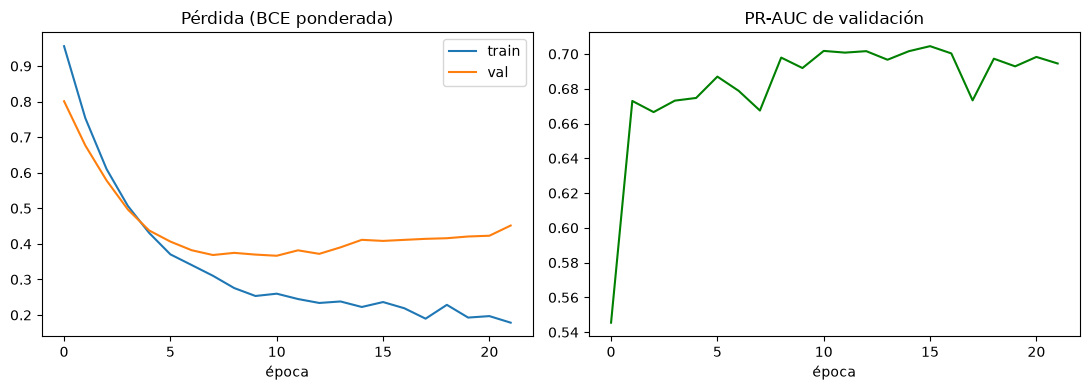

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Pérdida (BCE ponderada)"); ax[0].set_xlabel("época"); ax[0].legend()
ax[1].plot(history["val_ap"], color="green")
ax[1].set_title("PR-AUC de validación"); ax[1].set_xlabel("época")
plt.tight_layout(); plt.show()


## 6. Evaluación en TEST — PR-AUC primero

Reportamos **PR-AUC** (métrica principal) y ROC-AUC como referencia. La curva PR muestra el *trade-off* real precisión↔recall para distintos umbrales.

TEST  PR-AUC (Average Precision): 0.7152
TEST  ROC-AUC:                    0.9763


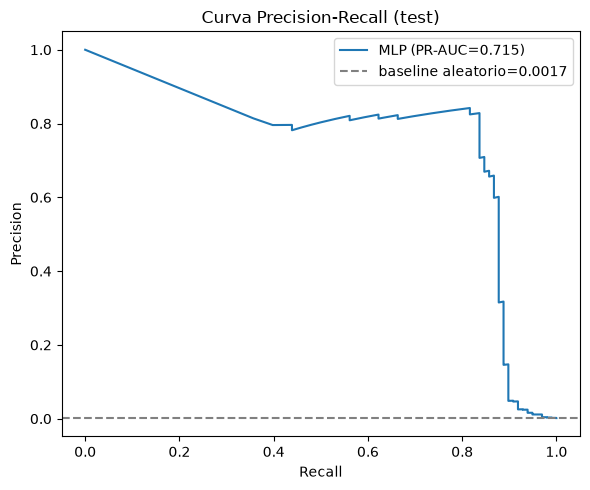

In [70]:
test_p, test_y = predict_proba(model, test_loader)

ap  = average_precision_score(test_y, test_p)
roc = roc_auc_score(test_y, test_p)
print(f"TEST  PR-AUC (Average Precision): {ap:.4f}")
print(f"TEST  ROC-AUC:                    {roc:.4f}")

prec, rec, thr = precision_recall_curve(test_y, test_p)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"MLP (PR-AUC={ap:.3f})")
plt.axhline(test_y.mean(), ls="--", color="gray", label=f"baseline aleatorio={test_y.mean():.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Curva Precision-Recall (test)")
plt.legend(); plt.tight_layout(); plt.show()


## 7. Ajuste de umbral (decisión de negocio)

El modelo entrega una **probabilidad**; el umbral 0.5 por defecto raramente es óptimo en datos desbalanceados. Elegimos el umbral que **maximiza F1** sobre la curva PR. En un caso real, este umbral se fija según el costo de un fraude no detectado vs. el costo de revisar un falso positivo

In [71]:
# F1 en CADA punto de la curva: F1 = 2·P·R/(P+R). El +1e-12 evita dividir por cero.
f1s = 2 * prec * rec / (prec + rec + 1e-12)
# Índice del F1 más alto. f1s[:-1] descarta el último punto (recall=0, precision=1) que NO tiene umbral asociado (thr trae un elemento menos). nanargmax ignora posibles NaN.
best_idx = int(np.nanargmax(f1s[:-1]))   
best_thr = thr[best_idx] # el umbral que corresponde a ese mejor F1
print(f"Umbral óptimo (max F1): {best_thr:.4f}  ->  F1={f1s[best_idx]:.4f}, "
      f"precision={prec[best_idx]:.4f}, recall={rec[best_idx]:.4f}")

# Aplicamos el umbral: probabilidad >= umbral -> 1 (fraude); si no -> 0. .astype(int) lo pasa a 0/1.
y_pred = (test_p >= best_thr).astype(int)
cm = confusion_matrix(test_y, y_pred)
print("\nMatriz de confusión [filas=real, cols=pred]:\n", cm)
# Tabla con precisión, recall, F1 y soporte (nº de casos) por clase.
print("\n", classification_report(test_y, y_pred, digits=4, target_names=["legítima", "fraude"]))


Umbral óptimo (max F1): 0.9979  ->  F1=0.8325, precision=0.8283, recall=0.8367

Matriz de confusión [filas=real, cols=pred]:
 [[56847    17]
 [   16    82]]

               precision    recall  f1-score   support

    legítima     0.9997    0.9997    0.9997     56864
      fraude     0.8283    0.8367    0.8325        98

    accuracy                         0.9994     56962
   macro avg     0.9140    0.9182    0.9161     56962
weighted avg     0.9994    0.9994    0.9994     56962



## 8. Validación cruzada

`StratifiedKFold` re-entrena el MLP en *k* particiones y reporta **PR-AUC media ± desviación**, evidencia de que el resultado no depende de un único split afortunado. Se re-ajusta el escalador *dentro de cada fold* (sin fuga). Reducimos épocas para que corra en CPU en tiempo razonable.

In [72]:
def cv_mlp(X_all, y_all, n_splits=5, max_epochs=15):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    aps = []
    Xv = X_all.values if hasattr(X_all, "values") else X_all
    # En cada vuelta, 'tr' y 'va' son los índices de entrenamiento y validación de ese fold.
    for fold, (tr, va) in enumerate(skf.split(Xv, y_all), 1):
        Xtr = X_all.iloc[tr].copy(); Xva = X_all.iloc[va].copy()
        ytr, yva = y_all[tr], y_all[va]
        # Escalado DENTRO del fold (sin fuga): el escalador se ajusta solo con el train del fold.
        sc = RobustScaler().fit(Xtr[cols_to_scale])
        Xtr[cols_to_scale] = sc.transform(Xtr[cols_to_scale])
        Xva[cols_to_scale] = sc.transform(Xva[cols_to_scale])

        # train_model y make_loader leen pos_weight_value (global), así que lo recalculamos para este fold y guardamos el anterior (pw_old) para restaurarlo después.
        global pos_weight_value
        pw_old = pos_weight_value
        pos_weight_value = (ytr == 0).sum() / (ytr == 1).sum()

        tl = make_loader(Xtr, ytr, shuffle=True)
        vl = make_loader(Xva, yva, shuffle=False)
        set_seed(SEED + fold) # semilla distinta por fold (variar la inicialización)
        m = MLP(Xtr.shape[1], HIDDEN_DIMS, DROPOUT).to(DEVICE) # red NUEVA en cada fold
        m, _, _ = train_model(m, tl, vl, max_epochs=max_epochs, patience=4, verbose=False) # menos épocas (CPU)
        p, yy = predict_proba(m, vl)
        ap_fold = average_precision_score(yy, p)
        aps.append(ap_fold)
        pos_weight_value = pw_old # PR-AUC de este fold
        print(f"  Fold {fold}: PR-AUC = {ap_fold:.4f}")
    aps = np.array(aps)
    print(f"\nPR-AUC CV: {aps.mean():.4f} ± {aps.std():.4f}")
    return aps

# Usa train+val (deja test intacto). Comenta si quieres ahorrar tiempo.
_ = cv_mlp(X_trainval.reset_index(drop=True), y_trainval, n_splits=5, max_epochs=15)


  Fold 1: PR-AUC = 0.8057
  Fold 2: PR-AUC = 0.7542
  Fold 3: PR-AUC = 0.6407
  Fold 4: PR-AUC = 0.8069
  Fold 5: PR-AUC = 0.7081

PR-AUC CV: 0.7431 ± 0.0630


## 9. Comparación: AdaBoost vs MLP

Se pide contrastar **AdaBoost frente a redes neuronales** con PR-AUC. Entrenamos un AdaBoost con la misma partición y superponemos sus curvas PR.

AdaBoost  PR-AUC=0.7610 | ROC-AUC=0.9760
MLP       PR-AUC=0.7152 | ROC-AUC=0.9763


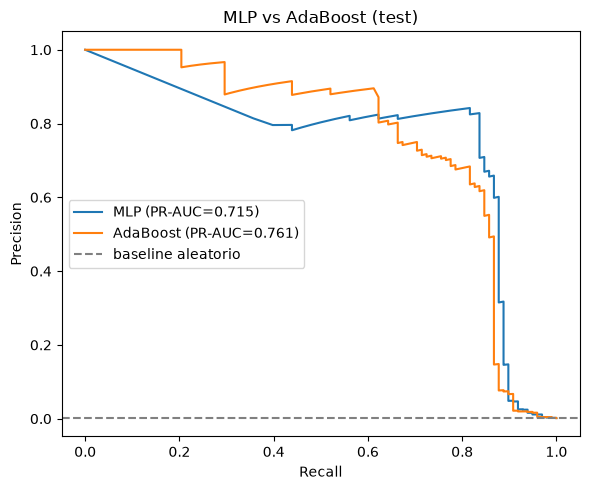

In [73]:
set_seed(SEED)
# AdaBoost: 300 "árboles débiles" combinados por boosting. learning_rate=0.5 modera su aporte.
ada = AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=SEED)
ada.fit(X_train.values, y_train)            # árboles: no requieren escalado
ada_p = ada.predict_proba(X_test.values)[:, 1] # probabilidad de la clase 1 (fraude): tomamos la columna 1
ada_ap = average_precision_score(test_y, ada_p)
ada_roc = roc_auc_score(test_y, ada_p)
print(f"AdaBoost  PR-AUC={ada_ap:.4f} | ROC-AUC={ada_roc:.4f}")
print(f"MLP       PR-AUC={ap:.4f} | ROC-AUC={roc:.4f}")

ap_prec, ap_rec, _ = precision_recall_curve(test_y, ada_p) # curva PR de AdaBoost
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"MLP (PR-AUC={ap:.3f})")
plt.plot(ap_rec, ap_prec, label=f"AdaBoost (PR-AUC={ada_ap:.3f})") # curva del MLP (reusa prec/rec de 6)
plt.axhline(test_y.mean(), ls="--", color="gray", label="baseline aleatorio") # curva de AdaBoost
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("MLP vs AdaBoost (test)")
plt.legend(); plt.tight_layout(); plt.show()


## XGBoost vs MLP

Se realiza una comparativa también con XGBoost y Random Forest, también se incluyen sus respectivas curvas PR, se utiliza el mismo numero de estimadores (300) para garantizar una comparativa justa 

XGBoost   PR-AUC=0.8794 | ROC-AUC=0.9722
MLP       PR-AUC=0.7152 | ROC-AUC=0.9763


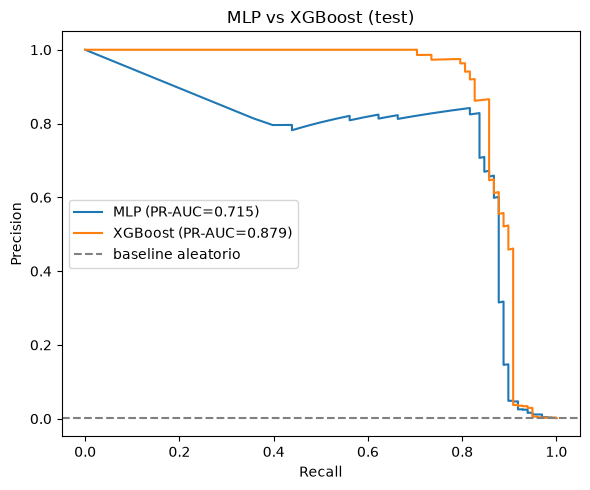

In [ ]:
set_seed(SEED)
# Usamos el pos_weight_value (~578) calculado previamente para la función de pérdida
xgb_clf = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, scale_pos_weight=pos_weight_value, random_state=SEED, eval_metric='logloss')
xgb_clf.fit(X_train.values, y_train)
xgb_p = xgb_clf.predict_proba(X_test.values)[:, 1]
xgb_ap = average_precision_score(test_y, xgb_p)
xgb_roc = roc_auc_score(test_y, xgb_p)
print(f"XGBoost   PR-AUC={xgb_ap:.4f} | ROC-AUC={xgb_roc:.4f}")
print(f"MLP       PR-AUC={ap:.4f} | ROC-AUC={roc:.4f}")


xgb_prec, xgb_rec, _ = precision_recall_curve(test_y, xgb_p) # curva PR de XGBoost
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"MLP (PR-AUC={ap:.3f})") # curva del MLP (reusa prec/rec de 6)
plt.plot(xgb_rec, xgb_prec, label=f"XGBoost (PR-AUC={xgb_ap:.3f})") # curva de XGBoost
plt.axhline(test_y.mean(), ls="--", color="gray", label="baseline aleatorio") 
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("MLP vs XGBoost (test)")
plt.legend(); plt.tight_layout(); plt.show()

Se ajustó el learning rate a 0.1 ya que en este caso, XGBoost es matemáticamente más avanzado que Adaboost, entonces si se elige un learning rate de 0.5 el modelo memorizaría el ruido de los datos de entrenamiento y aprendería rápido, esto generaría un sobreajuste.

Al elegir 0.1 XGBoost, se obliga al modelo a aprender de forma más lenta y esto causaria que se analicen de forma rigurosa los patrones de fraude sin memorizar el ruido de los datos de entrenamiento. Esto garantiza que el modelo final sea mucho más robusto y generalice mejor cuando se enfrente a datos de fraude nuevos en la vida real.

## Random Forest vs MLP

Su objetivo principal es reducir la varianza.

RandFor   PR-AUC=0.8562 | ROC-AUC=0.9654
MLP       PR-AUC=0.7152 | ROC-AUC=0.9763


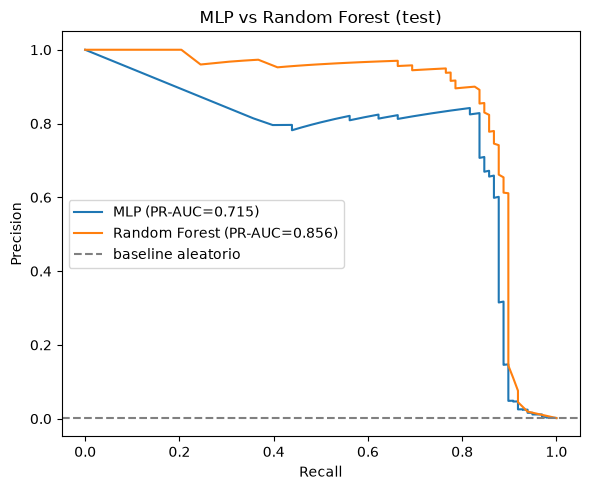

In [ ]:
set_seed(SEED)
# balanced penaliza más los errores en la clase minoritaria (fraude)
randomf_clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1) #n_jobs=-1 usa todos los núcleos de CPU disponibles para entrenar más rápido
randomf_clf.fit(X_train.values, y_train)
rf_p = randomf_clf.predict_proba(X_test.values)[:, 1]
rf_ap = average_precision_score(test_y, rf_p)
rf_roc = roc_auc_score(test_y, rf_p)
print(f"RandFor   PR-AUC={rf_ap:.4f} | ROC-AUC={rf_roc:.4f}")
print(f"MLP       PR-AUC={ap:.4f} | ROC-AUC={roc:.4f}")


rf_prec, rf_rec, _ = precision_recall_curve(test_y, rf_p) # curva PR de Random Forest
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"MLP (PR-AUC={ap:.3f})")
plt.plot(rf_rec, rf_prec, label=f"Random Forest (PR-AUC={rf_ap:.3f})") # curva de Random Forest
plt.axhline(test_y.mean(), ls="--", color="gray", label="baseline aleatorio") 
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("MLP vs Random Forest (test)")
plt.legend(); plt.tight_layout(); plt.show()

## Comparacion de los 3 ensambles vs MLP

Se realiza una superposición de los 3 ensambles (Random Forest, XGBoost y Adaboost) al compararse con MLP

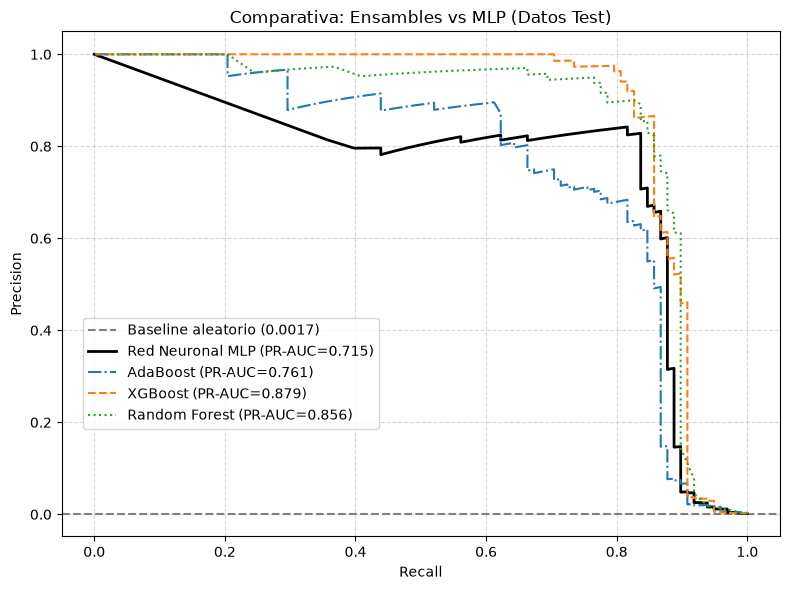

In [85]:
plt.figure(figsize=(8, 6))
#Curva del baseline aleatorio
plt.axhline(test_y.mean(), ls="--", color="gray", label=f"Baseline aleatorio ({test_y.mean():.4f})")
# Curvas de los modelos
plt.plot(rec, prec, label=f"Red Neuronal MLP (PR-AUC={ap:.3f})", color='black', linewidth=2)
plt.plot(ap_rec, ap_prec, label=f"AdaBoost (PR-AUC={ada_ap:.3f})", linestyle='-.')
plt.plot(xgb_rec, xgb_prec, label=f"XGBoost (PR-AUC={xgb_ap:.3f})", linestyle='--')
plt.plot(rf_rec, rf_prec, label=f"Random Forest (PR-AUC={rf_ap:.3f})", linestyle=':')


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Comparativa: Ensambles vs MLP (Datos Test)")
plt.legend(loc="lower left", bbox_to_anchor=(0.02, 0.2), frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

  Se puede observar que XGBoost es el que mayor porcentaje de efectividad tiene sin llegar a un sobreajuste con un PR-AUC=87.9

## 10. Interpretación de resultados 

Sobre un conjunto de prueba de 56,962 transacciones (98 fraudes, 0.17 %), el MLP
alcanzó **PR-AUC = 0.715** y ROC-AUC = 0.9763, frente a **PR-AUC = 0.761** y
ROC-AUC = 0.976 de AdaBoost.

**Por qué PR-AUC y no accuracy/ROC-AUC.** Con una prevalencia del 0.17 %, accuracy
es inútil (predecir "todo legítimo" da 99.83 %) y el ROC-AUC resulta
engañosamente alto porque premia la ordenación sobre la enorme clase mayoritaria.
El PR-AUC se concentra en la precisión entre los positivos predichos. De hecho, el
MLP supera marginalmente a AdaBoost en ROC-AUC pero queda por debajo en PR-AUC:
la demostración de libro de por qué PR-AUC es la métrica correcta aquí. El baseline
aleatorio en PR equivale a la prevalencia (≈0.0017), así que ambos modelos operan
entre 400 y 480 veces por encima del azar.

**MLP vs AdaBoost.** AdaBoost gana en PR-AUC porque el boosting sobre árboles
concentra el esfuerzo en los casos difíciles y modela bien las fronteras locales y
no lineales entre los componentes PCA, mientras que una red pequeña dispone de solo
492 fraudes para aprender una superficie suave; con tan pocos ejemplos de la clase
rara, la flexibilidad del MLP no se traduce en ventaja.

Al analizar los resultados obtenidos con los 3 diferentes ensambles y MLP, XGBoost 
es el más efectivo en PR-AUC (0.879) y es menor que Adaboost (0.9760) y MLP (0.9763) 
en ROC-AUC, aquí lo más importante es el valor PR-AUC, ya que solo evalúa qué tan 
se identifican los fraudes (Recall) y cuántas falsas alarmas disparas al hacerlo 
(precisión). El MLP y AdaBoost tienen un ROC-AUC altísimo porque son geniales 
reconociendo la normalidad, esto significa que los modelos son muy buenos detectando 
las transacciones seguras de todos los días (la clase mayoritaria) pero transacciones 
fraudulentas que no tengan comportamientos atípicos pasarían desapercibidas.

**Robustez.** La validación cruzada estratificada del MLP da PR-AUC = 0.7431 ± 0.0630,
consistente con el resultado en test (0.715), lo que descarta sobreajuste a un
único split.

**Pesos en la pérdida y umbral.** El desbalance se manejó con `pos_weight` ≈ 578 en
la BCE ponderada; sin él, el recall colapsa. Ese peso infla las probabilidades, por
lo que el umbral óptimo (máximo F1) cae en 0.998 en vez de 0.5, esta descalibración
es la razón por la que el ajuste de umbral es imprescindible. En ese punto el MLP
detecta 82 de 98 fraudes (recall 83.6 %) con 17 falsos positivos entre ~56,800
legítimas (precisión 82.8 %). La regularización L2 (`weight_decay`) estabiliza los
pesos, coherente con la correlación residual entre los componentes PCA.

**Conclusión.** En estos datos anonimizados por PCA y muy desbalanceados, el boosting
captura la señal mejor que un MLP pequeño. Basado en el PR-AUC final evaluado en el 
conjunto de prueba (datos nunca vistos), XGBoost demostró ser superior. Su capacidad 
de ensamble por gradiente, sumada a la penalización exacta en su función de pérdida, 
logró el mejor equilibrio empírico entre la precisión y la exhaustividad, superando 
la capacidad de generalización del MLP, Random Forest y AdaBoost para este contexto 
especifico.

In [77]:
# Guardado de artefactos reproducibles
import json as _json
os.makedirs("artifacts", exist_ok=True)
torch.save(model.state_dict(), "artifacts/mlp_fraud.pt")
metrics = {
    "mlp_pr_auc": float(ap), "mlp_roc_auc": float(roc),
    "adaboost_pr_auc": float(ada_ap), "adaboost_roc_auc": float(ada_roc),
    "xgboost_pr_auc": float(xgb_ap), "xgboost_roc_auc": float(xgb_roc),
    "random_forest_pr_auc": float(rf_ap), "random_forest_roc_auc": float(rf_roc),
    "best_threshold": float(best_thr), "best_val_pr_auc": float(best_val_ap),
    "pos_weight": float(pos_weight_value), "seed": SEED,
}
with open("artifacts/mlp_metrics.json", "w") as f:
    _json.dump(metrics, f, indent=2)
print("Guardado en artifacts/:", metrics)


Guardado en artifacts/: {'mlp_pr_auc': 0.7152145876314017, 'mlp_roc_auc': 0.976253222870465, 'adaboost_pr_auc': 0.7609536315049384, 'adaboost_roc_auc': 0.9759581220642449, 'xgboost_pr_auc': 0.8794109645456715, 'xgboost_roc_auc': 0.9721503436771445, 'random_forest_pr_auc': 0.856245232149782, 'random_forest_roc_auc': 0.965353873330424, 'best_threshold': 0.9978531002998352, 'best_val_pr_auc': 0.7044840736324276, 'pos_weight': 575.8227848101266, 'seed': 42}
